In [1]:

import numpy as np
import pandas as pd
import os
import argparse
from tqdm import tqdm


def check_file(file_path):
    data = np.load(file_path, allow_pickle=True)
    print(f"{data['param_names']}")
    print(f"{data['hitsE'].shape}")
    print(f"{data['hitsM'].shape}")
    print(f"{data['params'].shape}")

def merge_batch_files(batch_files, output_npz, param_names):
    
    """合并所有批次文件"""
    all_hitsE = []
    all_hitsM = []
    all_params = []

    for batch_file in tqdm(batch_files):
        data = np.load(batch_file, allow_pickle=True)
        all_hitsE.extend(data["hitsE"])
        all_hitsM.extend(data["hitsM"])
        all_params.extend(data["params"])
        del data
        # os.remove(batch_file)

    np.savez_compressed(output_npz,
                        hitsE=np.array(all_hitsE, dtype=object),
                        hitsM=np.array(all_hitsM, dtype=object),
                        params=np.array(all_params, dtype=object),
                        param_names=param_names)
    print(f"Merge {len(batch_files)} files to {output_npz}")
if __name__ == "__main__":
    selected_param_names = ["label", "weight",
                            "R_ue", "R_mean", "Eage", "compactness", "pincness","rho40",
                            "recE", "rec_x", "rec_y", "rec_theta", "rec_phi", 
                            "NpE3", "NuM1","NuM2","NuM3","NuM4","NuM5", 
                            "trueE", "core_x","core_y","theta","phi",
                            "dr","NuW3","NuW2", "mjd","tlong","tlat",
                            ]

    # Dir="/home/zhonghua/data/Dataset_Filted/Experiment/exp_muons"
    # npz_name="2023_0101_1e10_V04_dataset_muon.npz"
    # batch_files = []
    # gap=100000
    # # nentries=2967854
    # nentries_1=2500000
    # nentries_2=2967854
    # for n in range(nentries_1,nentries_2,gap):
    #     batch_start=n
    #     batch_end=min(n+gap,nentries_2)
    #     batch_files.append(f"{Dir}/{npz_name}_batch_{batch_start}_{batch_end-1}.npz")


    # batch_files=[f"{Dir}/{npz_name}_{n}.npz" for n in range(1,5)]
    # print(f"Merging batch {len(batch_files)} files...")
    # merge_batch_files(batch_files, f"{Dir}/{npz_name}.npz", selected_param_names)
    # check_file(batch_files[0])
    def npz_to_df_csv(npz_file):
        data = np.load(npz_file, allow_pickle=True)
        df = pd.DataFrame(data['params'], columns=data['param_names'])
        df.to_csv(npz_file.replace(".npz", ".csv"), index=False)
        print(df.head())

    npz_file="/data/home/zzh/data/Dataset_Filted/Experiment/exp_muons/combined_20240101_no_muon_cut_dataset_fastcode.npz"
    npz_to_df_csv(npz_file)


  label weight      R_ue     R_mean      Eage compactness  pincness  \
0    -1      1 -1.090243  44.935814  1.300251    0.326043  0.815385   
1    -1      1 -0.928886  54.454731  1.343963    0.647689  0.867021   
2    -1      1 -1.110626  48.629799  1.131073    0.483043   0.85034   
3    -1      1 -0.906707  55.827827  1.434098    0.629753  0.882629   
4    -1      1 -0.967875   57.04763  1.335666    0.628365  0.889344   

       rho40      recE       rec_x  ... core_x core_y theta phi          dr  \
0  72.874819  1.955384 -101.412552  ...   -1.0   -1.0  -1.0  -1   45.897644   
1   73.75947   2.12337  316.540558  ...   -1.0   -1.0  -1.0  -1  111.782814   
2  85.282984  1.918205 -140.031937  ...   -1.0   -1.0  -1.0  -1  159.194717   
3  83.494748  2.230137 -193.453705  ...   -1.0   -1.0  -1.0  -1  111.976486   
4  91.479131  2.290263  -80.393791  ...   -1.0   -1.0  -1.0  -1   90.454063   

       NuW3      NuW2           mjd       tlong       tlat  
0   2.62813  2.274835  60310.338219  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

exp_Rue2_2_file="/data/home/zzh/data/Dataset_Filted/Experiment/exp_Rue2_2/2023_1e10_V04_Rue2_2_dataset_muon.csv"
exp_Rue2_2_df=pd.read_csv(exp_Rue2_2_file)
exp_Rue2_2_df.columns


Index(['label', 'weight', 'R_ue', 'R_mean', 'Eage', 'compactness', 'pincness',
       'rho40', 'recE', 'rec_x', 'rec_y', 'rec_theta', 'rec_phi', 'NpE3',
       'NuM1', 'NuM2', 'NuM3', 'NuM4', 'NuM5', 'trueE', 'core_x', 'core_y',
       'theta', 'phi', 'dr', 'NuW3', 'NuW2', 'mjd', 'tlong', 'tlat'],
      dtype='object')

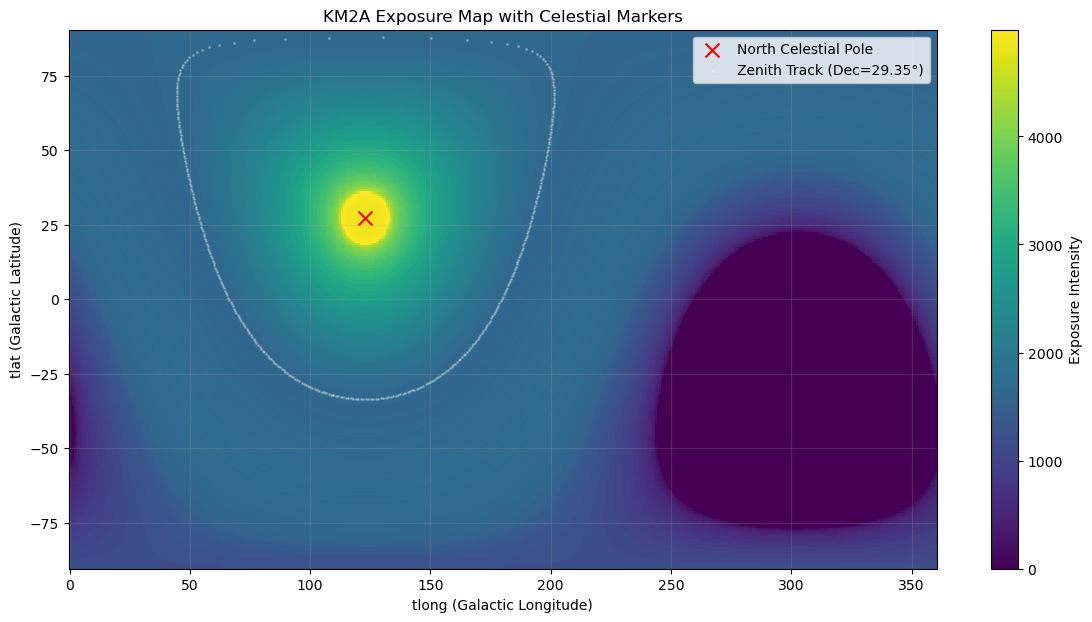

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from astropy import units as u
import uproot
from scipy.interpolate import interp1d

# --- 1. 加载数据 ---
file = uproot.open("/data/home/zzh/data/exposure_Gaisser.root")
h1 = file["h1"]
exposure_interp = interp1d(h1.axis().centers(), np.array(h1.values()), 
                           bounds_error=False, fill_value=0)

# --- 2. 坐标网格 ---
l_bins = np.linspace(0, 360, 500)
b_bins = np.linspace(-90, 90, 250)
L, B = np.meshgrid(l_bins, b_bins)

# 转换银道坐标到赤道坐标
gal_coords = SkyCoord(l=L*u.deg, b=B*u.deg, frame='galactic')
dec_rad = gal_coords.icrs.dec.radian

# --- 3. 计算曝光量 ---
lat_lhaaso = np.radians(29.35)
hour_angles = np.linspace(0, 2*np.pi, 144) 
cos_zenith = (np.sin(lat_lhaaso) * np.sin(dec_rad[:, :, np.newaxis]) + 
              np.cos(lat_lhaaso) * np.cos(dec_rad[:, :, np.newaxis]) * np.cos(hour_angles))
zeniths = np.degrees(np.arccos(np.clip(cos_zenith, -1, 1)))
exposure_map = np.sum(exposure_interp(zeniths), axis=2) / len(hour_angles)

# --- 4. 定义关键参考点 ---
# A. 北天极 (NCP): RA=任何, Dec=90
ncp = SkyCoord(ra=0*u.deg, dec=90*u.deg, frame='icrs').galactic
# B. LHAASO 天顶轨迹 (Zenith Track): Dec = 29.35, RA 走一圈
ra_track = np.linspace(0, 360, 360) * u.deg
dec_track = np.full(360, 29.35) * u.deg
zenith_track = SkyCoord(ra=ra_track, dec=dec_track, frame='icrs').galactic

# --- 5. 绘图 ---
plt.figure(figsize=(14, 7))
im = plt.pcolormesh(L, B, exposure_map, cmap='viridis', shading='auto')
plt.colorbar(im, label='Exposure Intensity')

# 绘制北天极 NCP (那个可能的亮斑点)
plt.scatter(ncp.l.deg, ncp.b.deg, color='red', marker='x', s=100, label='North Celestial Pole')

# 绘制天顶轨迹 (LHAASO 正上方扫过的区域)
# 注意：由于轨迹可能跨越 0/360 度，用 scatter 避免连线乱跳
plt.scatter(zenith_track.l.deg, zenith_track.b.deg, color='white', s=1, alpha=0.3, label='Zenith Track (Dec=29.35°)')

plt.xlabel('tlong (Galactic Longitude)')
plt.ylabel('tlat (Galactic Latitude)')
plt.title('KM2A Exposure Map with Celestial Markers')
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.show()


Loaded 218095
Loaded 1989943
Loaded 2967854


In [1]:
import numpy as np
import pandas as pd
import uproot
from xgboost import XGBRegressor

# --- 1. 配置参数 ---
BASE_PATH = "/data/home/zzh/data/Dataset_Filted/CosmicRay"
FILES = {
    "proton": "QF_Proton_addweight_rho_2.5e13_5.0e17_V3.root",
    "he":     "QF_He_addweight_rho_2.5e13_5.0e17_V3.root",
    "cno":    "QF_CNO_addweight_rho_2.5e13_5.0e17_V3.root",
    "fe":     "QF_Fe_addweight_rho_2.5e13_5.0e17_V3.root",
    "mgalsi": "QF_MgAlSi_addweight_rho_2.5e13_5.0e17_V3.root"
}

CUTS = (
    "rec_Eage > 0 and Redge > 0 and NuW3 > 0 and NpE3 > 250 "
    "and @theta_cut_low < rec_theta < @theta_cut_high"
)


# 阈值变量
r_cut_low, r_cut_high = 300, 450
theta_cut_low, theta_cut_high = np.deg2rad([0, 35])
log10TeV_low=1.8; log10TeV_high=2.3

# --- 2. 能量修正模型 ---
model = XGBRegressor();model._estimator_type = "regressor"
model.load_model("/data/home/zzh/Filt_Event/recE/models/energy_correction_xgb_NuW3_8-12_higher.json")
import json
        
# 加载线性参数
with open("/data/home/zzh/Filt_Event/recE/models/energy_correction_linear_params.json", 'r') as f:
    lp = json.load(f)
intercept  = lp["intercept"]
coef_NuW3  = lp["coef"][0]
coef_theta = lp["coef"][1]


# --- 3. 核心处理函数 ---
def process_cosmic_ray(name, filename):
    with uproot.open(f"{BASE_PATH}/{filename}") as f:
        # 读取数据
        branches = ["E", "theta", "phi", "corex", "corey", "rec_x", "rec_y", 
                    "rec_theta", "rec_phi", "rec_Eage", "Redge", "NpE3", "NuM1", "NuW3", "weightGaisser", "weightHorandol"]
        df = f["Rec"].arrays(branches, library="pd")
        
        print(f"Processing {name}: Entries={len(df)}, Weights={df['weightGaisser'].sum():.2e}")

        # 1. 基础物理筛选
        df = df.query(CUTS).copy()
        
        # 2. 计算特征量
        df["R_ue"] = np.log10((1e-4 + df["NuM1"]) / (df["NpE3"]))
        df["r"] = np.hypot(df['rec_x'], df['rec_y']) # 比 sqrt(x^2+y^2) 更快
        
        # 3. 半径进一步筛选
        df = df[(df["r"] > r_cut_low) & (df["r"] < r_cut_high)]
        df['NuW3'] = np.log10(df['NuW3'])
        # 4. XGBoost 能量修正
        features = df[["NuW3", "rec_theta"]].values
        df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
        print(f"     Finished {name}: Remaining Entries={len(df)}")

        return df[(df['recE']>log10TeV_low) & (df['recE']<log10TeV_high)]

# --- 4. 批量执行 ---
dfs = {name: process_cosmic_ray(name, path) for name, path in FILES.items()}
# 如果你需要解包到独立变量（虽然推荐直接用字典 dfs['proton']）
proton_df, he_df, cno_df, fe_df, mgalsi_df = dfs.values()
df_all_components = pd.concat(dfs.values(), ignore_index=True)
df_all_components['Eage'] = df_all_components['rec_Eage'] 
# ==========================================                





Processing proton: Entries=14217778, Weights=1.90e+02
     Finished proton: Remaining Entries=1698410
Processing he: Entries=14210418, Weights=2.03e+02
     Finished he: Remaining Entries=1166415
Processing cno: Entries=14218958, Weights=7.65e+01
     Finished cno: Remaining Entries=891738
Processing fe: Entries=14217887, Weights=7.40e+01
     Finished fe: Remaining Entries=736239
Processing mgalsi: Entries=14220016, Weights=3.57e+01
     Finished mgalsi: Remaining Entries=813815


In [2]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

def give_bkg_mc_weights_gaisser(pr_df: pd.DataFrame):
    rootfile = "/data/home/zzh/data/Dataset_Filted/Simulation/exposure_weight.root"
    with uproot.open(rootfile) as f:
        hWeight = f["hWeight"]
        edges_E = hWeight.axes[0].edges()  # Energy bin edges
        edges_Zen = hWeight.axes[1].edges()  # Zenith bin edges
        weights_2d = hWeight.values()

    def add_weights(trueE, rec_zenith, weights_2d):
        trueE=np.log10(trueE/1e3)
        rec_zenith=180/np.pi*rec_zenith
        bin_idx_E = np.digitize(trueE, edges_E) - 1
        bin_idx_Zen = np.digitize(rec_zenith, edges_Zen) - 1
        if bin_idx_E >= weights_2d.shape[0]:
            bin_idx_E = weights_2d.shape[0] - 1
        if bin_idx_Zen >= weights_2d.shape[1]:
            bin_idx_Zen = weights_2d.shape[1] - 1
        return weights_2d[bin_idx_E, bin_idx_Zen]
    
    pr_df['gaisser_weight']=pr_df.apply(lambda row: add_weights(row['trueE'],row['rec_theta'],weights_2d),axis=1)
    pr_df['gaisser_weight']=pr_df['gaisser_weight']/86400
    # print(f"======> Total expected background MC events after weighting: {pr_df['gaisser_weight'].sum()} ======")
    return pr_df

def load_pos(flag:int):
    ED_pos_file = None
    MD_pos_file = None
    script_dir = "/data/home/zzh/data/Dataset_Filted/config"
    if flag==7:
        ED_pos_file=f'{script_dir}/ED_pos_all_MC.txt'
        MD_pos_file=f'{script_dir}/MD_pos_all_MC.txt'
    else:
        MD_pos_file=f'{script_dir}/MD_pos_1188.txt'
        if flag>20191224 and flag<20201201:
            ED_pos_file=f'{script_dir}/ED_pos_half.txt'
        elif flag>20201130 and flag<20210720:
            ED_pos_file=f'{script_dir}/ED_pos_3978.txt'
        elif flag>20210719 and flag<20210807:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20210720.txt'
        elif flag>20210806 and flag<20210818:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20210807.txt'
        elif flag>20210817 and flag<20220525:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20210818.txt'
        elif flag>20220525 and flag<20220601:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20220520.txt'
        elif flag>20220531 and flag<20220705:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20220601.txt'
        elif flag>20220704:
            ED_pos_file=f'{script_dir}/ED_pos_5216up_20220705.txt'
    
    if ED_pos_file is not None:
        if os.path.exists(ED_pos_file) and os.path.exists(MD_pos_file):
            ED_pos=pd.read_csv(ED_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
            MD_pos=pd.read_csv(MD_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
            return ED_pos,MD_pos
    else:

        raise ValueError("wrong flag")
    
def event_plot_npz(index, hitsE_all, hitsM_all, df_params, flag=20240101, figpath=None):
    # 1. 加载阵列全量位置作为背景
    # 依然需要 load_pos 来获取该 flag 下所有探测器的坐标
    ED_pos, MD_pos = load_pos(flag)

    # 2. 提取当前事例的 hit 数据 (N, 5) -> x, y, r, pe, dt
    hE = hitsE_all[index]
    hM = hitsM_all[index]
    
    # 提取重建参数
    row = df_params.iloc[index]
    core = [row['rec_x'], row['rec_y']]
    theta, phi = row['rec_theta'], row['rec_phi']

    # 3. 计算指向箭头
    dy = np.sin(theta) * np.cos(phi)
    dx = -np.sin(theta) * np.sin(phi)
    dr = np.sqrt(dx**2 + dy**2)
    arrow_len = 200
    if dr > 0:
        dx, dy = dx * arrow_len / dr, dy * arrow_len / dr

    # 4. 开始绘图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- 左图：ED Hits ---
    # 背景：所有 ED 位置
    ax1.scatter(ED_pos['x'], ED_pos['y'], c='lightgray', s=1, alpha=0.3, label='Detectors')
    # 前景：命中的 ED (hE[:, 3] 是 pe)
    sc1 = ax1.scatter(hE[:, 0], hE[:, 1], c=np.log10(hE[:, 3] + 1), 
                      cmap='viridis', s=5, zorder=3)
    
    ax1.scatter(core[0], core[1], c='red', s=60, marker='x', label='Core', zorder=5)
    ax1.arrow(core[0], core[1], dx, dy, color='orange', width=2, head_width=15, zorder=6)
    
    ax1.set_title('ED Channel Hits', fontweight='bold')
    fig.colorbar(sc1, ax=ax1, label='log10 PE')

    # --- 右图：MD Hits ---
    # 背景：所有 MD 位置
    ax2.scatter(MD_pos['x'], MD_pos['y'], c='lightgray', s=4, alpha=0.3)
    # 前景：命中的 MD
    sc2 = ax2.scatter(hM[:, 0], hM[:, 1], c=np.log10(hM[:, 3] + 1), 
                      cmap='viridis', s=15, zorder=3)
    
    ax2.scatter(core[0], core[1], c='red', s=60, marker='x', zorder=5)
    
    ax2.set_title('MD Channel Hits', fontweight='bold')
    fig.colorbar(sc2, ax=ax2, label='log10 PE')

    # 格式化标题
    res_info = (f"Event {index} | R_mean: {row['R_mean']:.2f}\n"
                f"Core: [{core[0]:.1f}, {core[1]:.1f}] | "
                f"Theta: {np.degrees(theta):.1f}°, Phi: {np.degrees(phi):.1f}°")
    plt.suptitle(res_info, fontsize=12)
    
    for ax in [ax1, ax2]:
        ax.set_aspect('equal') # 保持物理比例
        ax.set_xlabel('X [m]')
        ax.set_ylabel('Y [m]')
        ax.set_xlim(-650,650)
        ax.set_ylim(-650,650)
        ax.grid(True, linestyle=':', alpha=0.4)

    plt.tight_layout()
    # if figpath:
    #     plt.savefig(figpath, dpi=150, bbox_inches='tight')
    plt.show()

def energy_rec(df):
    df['NuW3'] = pd.to_numeric(df['NuW3'], errors='coerce')
    df['NuW3'] = np.log10(df['NuW3'])
    # 4. XGBoost 能量修正
    features = df[["NuW3", "rec_theta"]].values
    df["recE"] = model.predict(features) + intercept + coef_NuW3 * df['NuW3'] + coef_theta * df['rec_theta']
    return df


# --- 1. 加载数据 ---
# mc_data=np.load( "/data/home/zzh/data/Dataset_Filted/Simulation/1e10_V04/Proton_combined_filted_1e10_V04_dataset_fastcode.npz", allow_pickle=True)
# mc_hitsE=mc_data['hitsE'];mc_hitsM = mc_data['hitsM']; mc_params = mc_data['params']; mc_param_names = mc_data['param_names'];print(f'Loaded {len(mc_data["hitsE"])}'); del mc_data
# mc_df = pd.DataFrame(mc_params, columns=mc_param_names)
# mc_df['rec_x']= pd.to_numeric(mc_df['rec_x'], errors='coerce'); mc_df['rec_y'] = pd.to_numeric(mc_df['rec_y'], errors='coerce'); mc_df['rec_r']=np.sqrt(mc_df['rec_x']**2 + mc_df['rec_y']**2)
# mc_df = give_bkg_mc_weights_gaisser(mc_df)
# mc_df = energy_rec(mc_df)
npz_file="/data/home/zzh/data/Dataset_Filted/Experiment/1e10_V04/1e10_V04_2023_ALL_MERGED.npz"
data = np.load(npz_file, allow_pickle=True); df = pd.DataFrame(data['params'], columns=data['param_names']); del data
# df = pd.read_csv("/data/home/zzh/data/Dataset_Filted/Experiment/Rue1less_minus2/2024_Rue_minus1.9_noAge_cut_1e10_V04_dataset_fastcode.csv"); print(f'Loaded {len(df)}')
df['rec_x'] = pd.to_numeric(df['rec_x'], errors='coerce'); df['rec_y'] = pd.to_numeric(df['rec_y'], errors='coerce'); df['rec_r']=np.sqrt(df['rec_x']**2 + df['rec_y']**2)
df = energy_rec(df)
exp_Rue_df = df[(df['rec_r']>r_cut_low) & (df['rec_r']<r_cut_high) & (df['rec_theta'] > theta_cut_low) & (df['rec_theta'] < theta_cut_high)]
print(f"\n Exp data: {len(exp_Rue_df)} events")

# R_ue control region df
# one_day_data=pd.read_csv("/data/home/zzh/data/Dataset_Filted/Experiment/exp_muons/2023_0101_1e10_V04_dataset_muon.csv"); print(f'Loaded {len(one_day_data)}')
one_day_file="/data/home/zzh/data/Dataset_Filted/Simulation/1e10_V04/exp_1e10_V04_20230101_226files_dataset_fastcode.npz"
one_day= np.load(one_day_file, allow_pickle=True)
one_day_data = pd.DataFrame(one_day['params'], columns=one_day['param_names']); del one_day
one_day_data = energy_rec(one_day_data)
one_day_data['rec_x']= pd.to_numeric(one_day_data['rec_x'], errors='coerce'); one_day_data['rec_y'] = pd.to_numeric(one_day_data['rec_y'], errors='coerce'); one_day_data['rec_r']=np.sqrt(one_day_data['rec_x']**2 + one_day_data['rec_y']**2)
one_day_df = one_day_data[(one_day_data['rec_r']>r_cut_low) & (one_day_data['rec_r']<r_cut_high) & (one_day_data['rec_theta'] > theta_cut_low) & (one_day_data['rec_theta'] < theta_cut_high)]
print(f"One day data: {len(one_day_df)} events")




 Exp data: 28820 events
One day data: 70665 events


------------------------------
Processing Experimental Data...
Exp Data: 265825 -> 70665 events (after cuts)
------------------------------
Merging MC Components...
Total MC Events: 2328572
Total MC Flux Weight: 1.43e+01
------------------------------
Calculating Systematics Shifts (Data - MC)...

[recE Shift]
  Mean Data: 1.9757
  Mean MC  : 1.9760
  Shift (Data-MC): -0.0003
  Recommended UNC_E: 0.0003 (or conservative 0.05)

[R_ue Shift]
  Mean Data: -0.8989
  Mean MC  : -0.9024
  Shift (Data-MC): 0.0035
  Recommended UNC_RUE: 0.0035

[Eage Shift]
  Mean Data: 1.3323
  Mean MC  : 1.3039
  Shift (Data-MC): 0.0284, 0.0296
  Recommended UNC_EAGE: 0.0284

[rec_theta Shift]
  Mean Data: 0.3910
  Mean MC  : 0.3580
  Shift (Data-MC): 0.0329
  Recommended UNC_THETA: 0.0329


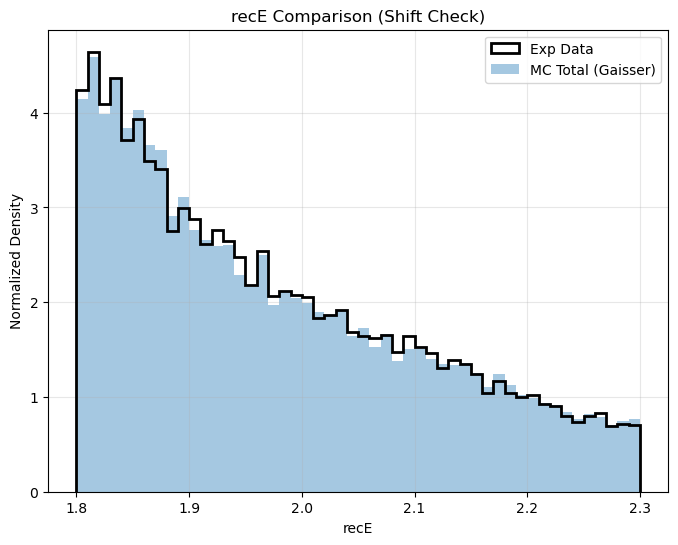

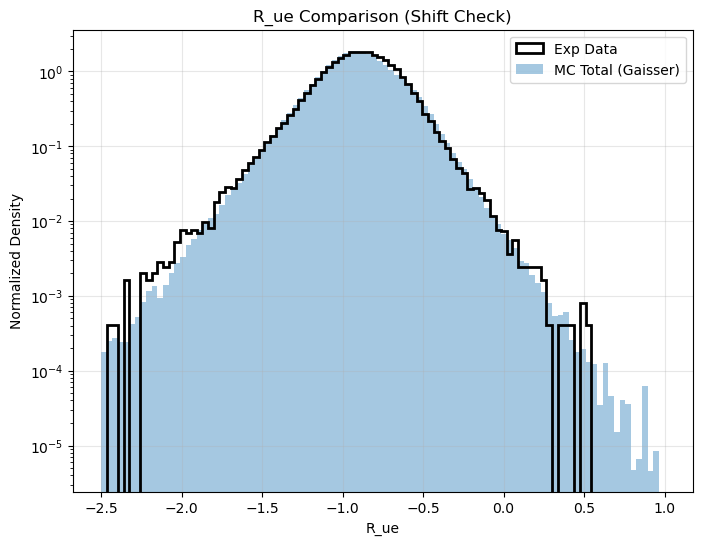

In [6]:
import numpy as np
import pandas as pd

# 切选字符串 (注意：NuW3 在 query 时通常是线性的，未取 log 前)
CUTS_QUERY = (
    "rec_Eage > 0 and NuW3 > 0 "
    "and @theta_cut_low < rec_theta < @theta_cut_high "
    "and @log10TeV_low < recE < @log10TeV_high"
)
CUTS_QUERY_exp = (
    "Eage > 0 and NuW3 > 0 "
    "and @theta_cut_low < rec_theta < @theta_cut_high "
    "and @log10TeV_low < recE < @log10TeV_high"
)


# ==========================================
# 1. 处理实验数据 (Apply Same Cuts)
# ==========================================
print("-" * 30)
print("Processing Experimental Data...")

# 1. 复制一份以免修改原数据
exp_df = one_day_data.copy()

# 2. 补充必要的几何变量 (如果 CSV 里没有 r)
# 假设 rec_x, rec_y 存在于 CSV 中
if 'r' not in exp_df.columns:
    exp_df["r"] = np.hypot(exp_df['rec_x'], exp_df['rec_y'])

# 3. 应用基础物理切选 (rec_Eage, Theta, etc.)
# 假设 CSV 列名与 MC 保持一致
before_cut = len(exp_df)
exp_df = exp_df.query(CUTS_QUERY_exp)

# 4. 应用半径切选
exp_df = exp_df[(exp_df["r"] > r_cut_low) & (exp_df["r"] < r_cut_high)]

# 5. 应用能量切选 (recE 已存在于 CSV)
exp_df = exp_df[(exp_df['recE'] > log10TeV_low) & (exp_df['recE'] < log10TeV_high)]

print(f"Exp Data: {before_cut} -> {len(exp_df)} events (after cuts)")

# ==========================================
# 2. 合并 MC 数据 (Weighted Concatenation)
# ==========================================
print("-" * 30)
print("Merging MC Components...")

# 将之前处理好的 5 个 DataFrame 合并
# 假设 dfs 是上一段代码生成的字典
mc_df_list = []
for name, df in dfs.items():
    temp_df = df.copy()
    temp_df['component'] = name  # 标记成分 (可选)
    mc_df_list.append(temp_df)

mc_total = pd.concat(mc_df_list, ignore_index=True)
print(f"Total MC Events: {len(mc_total)}")
print(f"Total MC Flux Weight: {mc_total['weightGaisser'].sum():.2e}")

# ==========================================
# 3. 计算偏移量 (Shift Calculation)
# ==========================================
print("-" * 30)
print("Calculating Systematics Shifts (Data - MC)...")

def get_weighted_stats(values, weights=None, val_range=None):
    """计算加权均值"""
    if weights is None:
        weights = np.ones(len(values))
    # 如果提供了 val_range，可以先筛选出范围内的值和对应的权重
    if val_range is not None:
        mask = (values >= val_range[0]) & (values <= val_range[1])
        values_masked = values[mask]
        weights_masked = weights[mask]
    else:
        values_masked = values
        weights_masked = weights
    # 计算加权均值
    if np.sum(weights_masked) == 0:
        return np.nan, np.nan
    else:
        average = np.average(values_masked, weights=weights_masked)
        # 也可以计算加权标准差用于参考
        variance = np.average((values_masked - average)**2, weights=weights_masked)
        return average, np.sqrt(variance)

# --- A. 计算 recE 的偏移 ---
# Exp (无权重或权重为1)
mu_exp_E, std_exp_E = get_weighted_stats(exp_df['recE'])
# MC (使用 Gaisser 权重)
mu_mc_E, std_mc_E = get_weighted_stats(mc_total['recE'], mc_total['weightGaisser'])

diff_E = mu_exp_E - mu_mc_E
print(f"\n[recE Shift]")
print(f"  Mean Data: {mu_exp_E:.4f}")
print(f"  Mean MC  : {mu_mc_E:.4f}")
print(f"  Shift (Data-MC): {diff_E:.4f}") 
print(f"  Recommended UNC_E: {abs(diff_E):.4f} (or conservative {max(0.05, abs(diff_E)):.2f})")

# --- B. 计算 R_ue 的偏移 ---
# 注意：确保 Data 也是在 CR 区域 (Rue > -2)
# 代码逻辑中 exp_df 已经是 CR 数据了，但为了严谨，我们计算 Shift 时
# 最好限制 MC 也只看 Rue > -2 的部分 (Sideband Comparison)，或者看峰值位置
# 这里我们直接比较整体均值 (假设都在 Background Region)

# 如果想更严谨，取 -4 < Rue < -1.8 这种纯背景区计算
# 这里演示全范围计算（基于前面已经做过的筛选）
mu_exp_R, std_exp_R = get_weighted_stats(exp_df['R_ue'])
mu_mc_R, std_mc_R = get_weighted_stats(mc_total['R_ue'], mc_total['weightGaisser'])

diff_R = mu_exp_R - mu_mc_R
print(f"\n[R_ue Shift]")
print(f"  Mean Data: {mu_exp_R:.4f}")
print(f"  Mean MC  : {mu_mc_R:.4f}")
print(f"  Shift (Data-MC): {diff_R:.4f}")
print(f"  Recommended UNC_RUE: {abs(diff_R):.4f}")

# --- C. 计算 Eage 的偏移 ---
age_range = (0.9, 1.6)  # Eage 的合理范围
mu_exp_Eage, std_exp_Eage = get_weighted_stats(exp_df['Eage'], val_range=age_range)
mu_mc_Eage, std_mc_Eage = get_weighted_stats(mc_total['rec_Eage'], mc_total['weightGaisser'], val_range=age_range)
mu_mc_Eage_horandel, std_mc_Eage_horandel = get_weighted_stats(mc_total['rec_Eage'], mc_total['weightHorandol'], val_range=age_range)
diff_Eage = mu_exp_Eage - mu_mc_Eage
diff_Eage_horandel = mu_exp_Eage - mu_mc_Eage_horandel
print(f"\n[Eage Shift]")
print(f"  Mean Data: {mu_exp_Eage:.4f}")
print(f"  Mean MC  : {mu_mc_Eage:.4f}")
print(f"  Shift (Data-MC): {diff_Eage:.4f}, {diff_Eage_horandel:.4f}")
print(f"  Recommended UNC_EAGE: {abs(diff_Eage):.4f}")

# --- D. 计算 rec_theta 的偏移 ---
mu_exp_theta, std_exp_theta = get_weighted_stats(exp_df['rec_theta'])
mu_mc_theta, std_mc_theta = get_weighted_stats(mc_total['rec_theta'], mc_total['weightGaisser'])

diff_theta = mu_exp_theta - mu_mc_theta
print(f"\n[rec_theta Shift]")
print(f"  Mean Data: {mu_exp_theta:.4f}")
print(f"  Mean MC  : {mu_mc_theta:.4f}")
print(f"  Shift (Data-MC): {diff_theta:.4f}")
print(f"  Recommended UNC_THETA: {abs(diff_theta):.4f}")
# ==========================================
# 4. 可视化验证 (强烈建议)
# ==========================================
import matplotlib.pyplot as plt

def plot_comparison(var_name, bins, range_val, log=False):
    plt.figure(figsize=(8, 6))
    
    # Plot Exp (Density)
    plt.hist(exp_df[var_name], bins=bins, range=range_val, density=True,
             histtype='step', color='black', label='Exp Data', lw=2)
    
    # Plot MC (Density + Weighted)
    plt.hist(mc_total[var_name], bins=bins, range=range_val, weights=mc_total['weightGaisser'],
             density=True, histtype='stepfilled', alpha=0.4, label='MC Total (Gaisser)')
    
    plt.title(f"{var_name} Comparison (Shift Check)")
    plt.xlabel(var_name)
    plt.ylabel("Normalized Density")
    plt.legend()
    if log: plt.yscale('log')
    plt.grid(alpha=0.3)
    plt.savefig(f"/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_{var_name}_shift.pdf", dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison('recE', 50, (1.8, 2.3))
# R_ue 通常看 -4 到 0 的范围
plot_comparison('R_ue', 100, (-2.5, 1), log=True)
# plot_comparison('rec_Eage', 50, (0.8, 1.8))
# plot_comparison('rec_theta', 50, (0, 0.63))


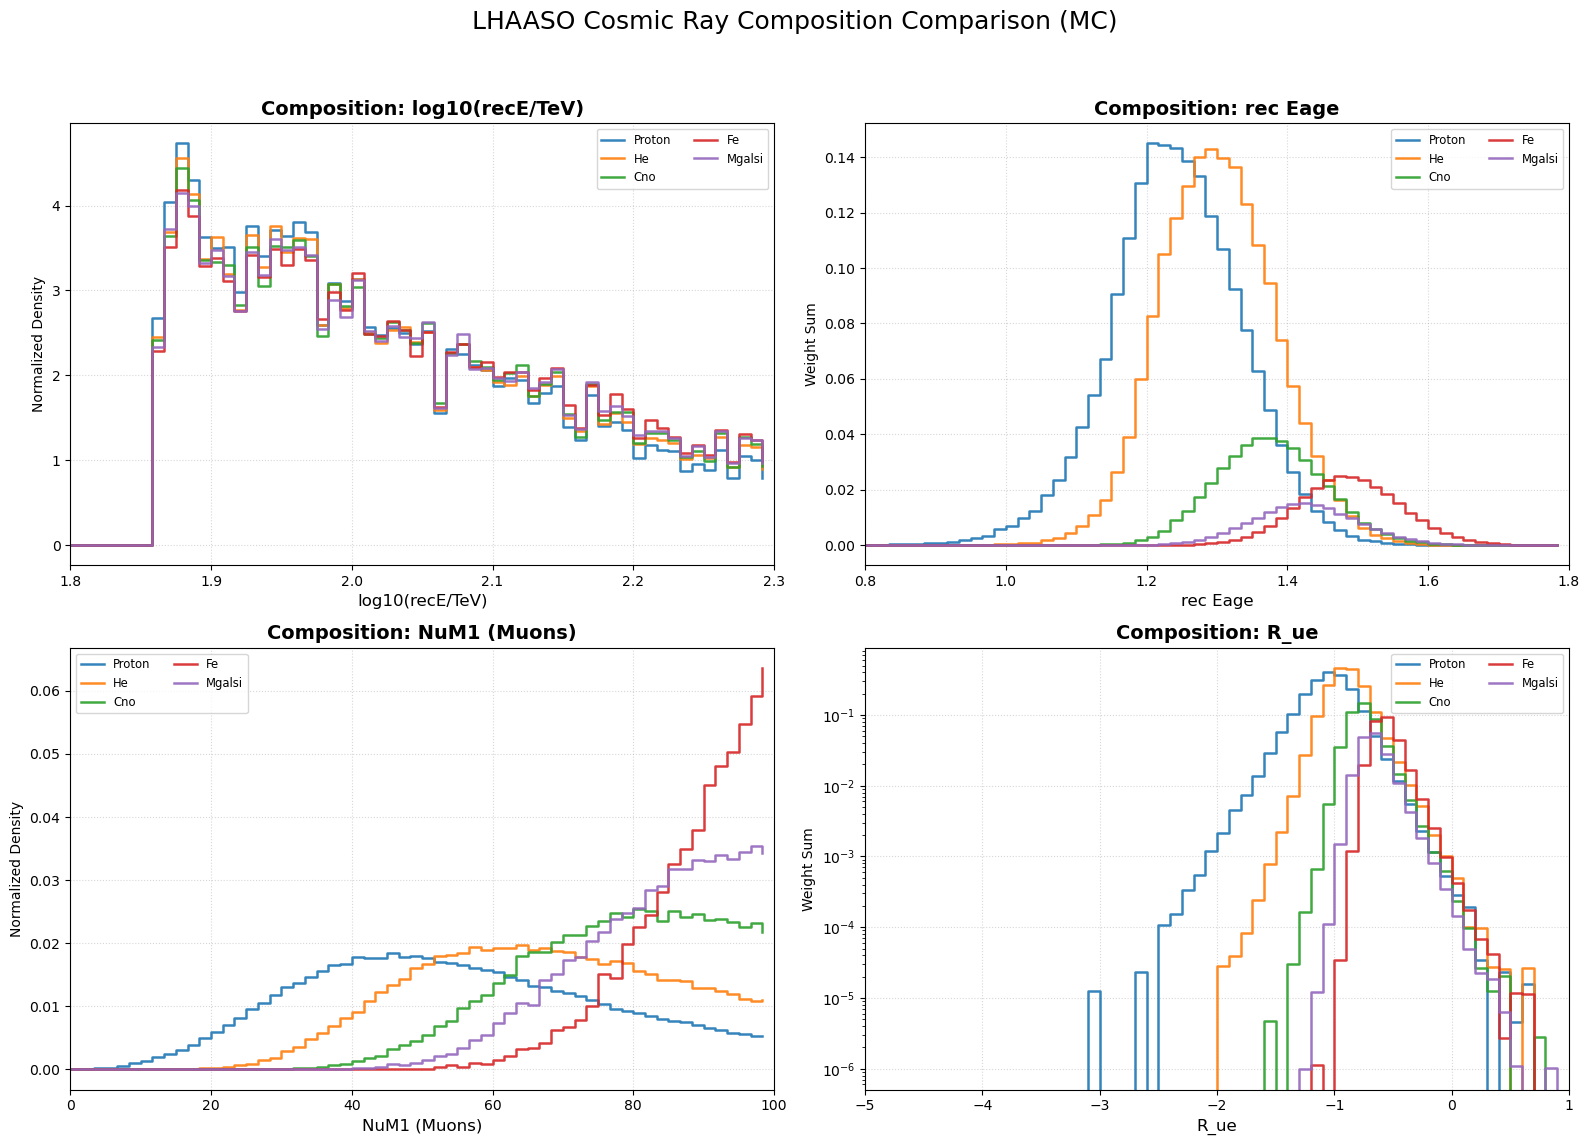

In [5]:
def plot_composition_comparison(dfs, figsize=(16, 12)):
    # 1. 定义要对比的参数配置
    # 这里的 range 可以根据你的数据物理范围微调
    param_configs = {
        "recE":      {"range": (1.8, 2.3),  "log": False, "density": True, "label": "log10(recE/TeV)"},
        "rec_Eage": {"range": (0.8,1.8),     "log": False,  "density": False, "label": "rec Eage"},
        "NuM1":      {"range": (0, 100),    "log": False,  "density": True, "label": "NuM1 (Muons)"},
        "R_ue":      {"range": (-5, 1),     "log": True, "density": False, "label": "R_ue"}
    }

    params = list(param_configs.keys())
    n_params = len(params)
    n_cols = 2
    n_rows = 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    # 定义物种对应的固定颜色，方便对比
    color_map = {
        "proton": "#1f77b4", # 蓝色
        "he":     "#ff7f0e", # 橙色
        "cno":    "#2ca02c", # 绿色
        "mgalsi": "#9467bd", # 紫色
        "fe":     "#d62728"  # 红色
    }

    for idx, p_name in enumerate(params):
        ax = axes[idx]
        cfg = param_configs[p_name]
        
        for name, df in dfs.items():
            if p_name not in df.columns:
                continue
            
            # 使用 NumPy 加速预计算
            vals = df[p_name].values.astype(float)
            weights = df["weightGaisser"].values.astype(float)
            
            # 过滤无效值
            mask = ~np.isnan(vals) & ~np.isinf(vals)
            
            # 计算直方图
            counts, bin_edges = np.histogram(
                vals[mask], bins=60, range=cfg['range'], 
                weights=weights[mask], density=cfg['density']
            )
            
            # 使用 step 绘图
            ax.step(bin_edges[:-1], counts, where='post', 
                    label=name.capitalize(), color=color_map.get(name), 
                    linewidth=1.8, alpha=0.9)

        # 子图美化
        ax.set_title(f"Composition: {cfg['label']}", fontweight='bold', fontsize=14)
        ax.set_xlabel(cfg['label'], fontsize=12)
        ax.set_ylabel("Normalized Density" if cfg['density'] else "Weight Sum")
        
        if cfg['log']:
            ax.set_yscale('log')
        
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize='small', ncol=2)
        if cfg['range']:
            ax.set_xlim(cfg['range'])

    plt.suptitle("LHAASO Cosmic Ray Composition Comparison (MC)", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 执行绘图 ---
plot_composition_comparison(dfs)


In [ ]:
# df_all_components = pd.concat(dfs.values(), ignore_index=True)
# # ==========================================                
# exp_Rue_df = df[(df['rec_r']>r_cut_low) & (df['rec_r']<r_cut_high) & (df['rec_theta'] > theta_cut_low) & (df['rec_theta'] < theta_cut_high) & (df['recE'] > log10TeV_low) & (df['recE'] < log10TeV_high)]
# print(f"\n Exp data: {len(exp_Rue_df)} events")
# 利用上述df_all_components和exp_Rue_df 
# 比较R_ue 在区间[-3,-2.5] ,[-2.5,2]时,参数Eage, rho40分布,density=True
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec

def plot_variable_comparison_in_rue_bins(mc_df, data_df, rue_ranges, variables, figsize=(12, 10)):
    """
    在指定的 Rue 区间内，对比 MC 和 Data 的变量分布。
    """
    # 1. 学术风格设置
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.linewidth": 1.2,
        "xtick.top": True,
        "ytick.right": True
    })

    # 布局：行数 = 区间数，列数 = 变量数
    n_rows = len(rue_ranges)
    n_cols = len(variables)
    
    fig = plt.figure(figsize=figsize, dpi=300)
    # 使用 GridSpec 以便未来扩展比率图 (Ratio Plot)
    gs = gridspec.GridSpec(n_rows, n_cols, hspace=0.3, wspace=0.25)

    # 变量配置 (Label 和 Range)
    var_configs = {
        'Eage':  {'label': r'Shower Age ($s_{\mathrm{age}}$)', 'range': (0.8, 1.6), 'bins': 40},
        'rho40': {'label': r'$\rho_{40}$ [m$^{-2}$]', 'range': (0, 150), 'bins': 50}
    }

    # 循环绘制
    for i, (r_low, r_high) in enumerate(rue_ranges):
        
        # --- 1. 数据切片 ---
        # MC 切片
        mask_mc = (mc_df['R_ue'] >= r_low) & (mc_df['R_ue'] < r_high)
        mc_slice = mc_df[mask_mc]
        
        # Data 切片
        mask_data = (data_df['R_ue'] >= r_low) & (data_df['R_ue'] < r_high)
        data_slice = data_df[mask_data]
        
        range_label = rf"${r_low} \leq R_{{\mu/e}} < {r_high}$"

        for j, var in enumerate(variables):
            ax = fig.add_subplot(gs[i, j])
            cfg = var_configs.get(var, {'label': var, 'range': None, 'bins': 40})
            
            # --- 2. 准备数据 ---
            # MC 数据
            vals_mc = mc_slice[var].values
            # 兼容不同的权重列名
            w_col_mc = 'gaisser_weight' if 'gaisser_weight' in mc_slice.columns else 'weight'
            weights_mc = mc_slice[w_col_mc].values if w_col_mc in mc_slice.columns else np.ones(len(mc_slice))
            
            # Exp 数据
            vals_data = data_slice[var].values
            weights_data = data_slice['weight'].values if 'weight' in data_slice.columns else np.ones(len(data_slice))

            # --- 3. 计算直方图 (Density=True) ---
            # 使用 numpy 预计算以获得正确的 errorbar
            hist_mc, bin_edges = np.histogram(vals_mc, bins=cfg['bins'], range=cfg['range'], weights=weights_mc, density=True)
            hist_data, _ = np.histogram(vals_data, bins=cfg['bins'], range=cfg['range'], weights=weights_data, density=True)
            
            # 计算 Data 的统计误差 (近似: err ~ sqrt(N) / N * density)
            # 需要先算原始计数来确定相对误差
            raw_counts_data, _ = np.histogram(vals_data, bins=cfg['bins'], range=cfg['range'])
            valid_mask = raw_counts_data > 0
            
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            yerr_data = np.zeros_like(hist_data)
            yerr_data[valid_mask] = hist_data[valid_mask] * (1.0 / np.sqrt(raw_counts_data[valid_mask]))

            # --- 4. 绘图 ---
            
            # A. 绘制 MC (红色实线 + 填充)
            ax.step(bin_centers, hist_mc, where='mid', color='#d62728', lw=1.5, label='Simulation (Total)')
            ax.fill_between(bin_centers, hist_mc, step='mid', color='#d62728', alpha=0.1)
            
            # B. 绘制 Data (黑色误差棒)
            ax.errorbar(bin_centers[valid_mask], hist_data[valid_mask], yerr=yerr_data[valid_mask], 
                        fmt='o', color='black', markersize=3, capsize=0, elinewidth=1.0, label='Exp. Data')

            # --- 5. 装饰 ---
            # 仅在第一行或特定位置显示标题
            if i == 0:
                ax.set_title(f"Variable: {var}", fontsize=13, fontweight='bold', pad=10)
            
            # 在图内标注 R_ue 范围
            ax.text(0.05, 0.95, range_label, transform=ax.transAxes, 
                    fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            # 仅在底部显示 X 轴标签
            if i == n_rows - 1:
                ax.set_xlabel(cfg['label'], fontsize=12)
            
            ax.set_ylabel("Normalized Density", fontsize=11)
            ax.legend(loc='best', frameon=False, fontsize=9)
            ax.grid(True, linestyle=':', alpha=0.4)
            
            # 自动调整 Y 轴上限，留出空间给 Legend 和 Text
            max_y = max(np.max(hist_mc), np.max(hist_data))
            ax.set_ylim(0, max_y * 1.4)

    # plt.tight_layout()
    # plt.savefig("Comparison_Eage_rho40_in_Rue_bins.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 执行调用
# ==========================================

# 1. 定义您要求的 Rue 区间
# 注意：您提到的第二个区间是 [-2.5, 2]，这跨度很大，通常包含质子主导区
rue_bins = [
    (-3.0, -1.9), 
]

# 2. 定义要画的变量
vars_to_plot = ['Eage',]

# 3. 运行绘图
# 假设 df_all_components 和 exp_Rue_df 已经在内存中
print(f"Comparing MC ({len(df_all_components)}) vs Data ({len(exp_Rue_df)}) ...")
plot_variable_comparison_in_rue_bins(df_all_components, exp_Rue_df, rue_bins, vars_to_plot)
rue_bins = [
    (-1.9, -1.5), 
]

# 2. 定义要画的变量
vars_to_plot = ['Eage',]

# 3. 运行绘图
# 假设 df_all_components 和 exp_Rue_df 已经在内存中
print(f"Comparing MC ({len(df_all_components)}) vs Data ({len(one_day_data)}) ...")
plot_variable_comparison_in_rue_bins(df_all_components, one_day_df, rue_bins, vars_to_plot)


Plotting Data Evolution...
Saving figure to /data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Data_age_stability_with_Rue.pdf ...


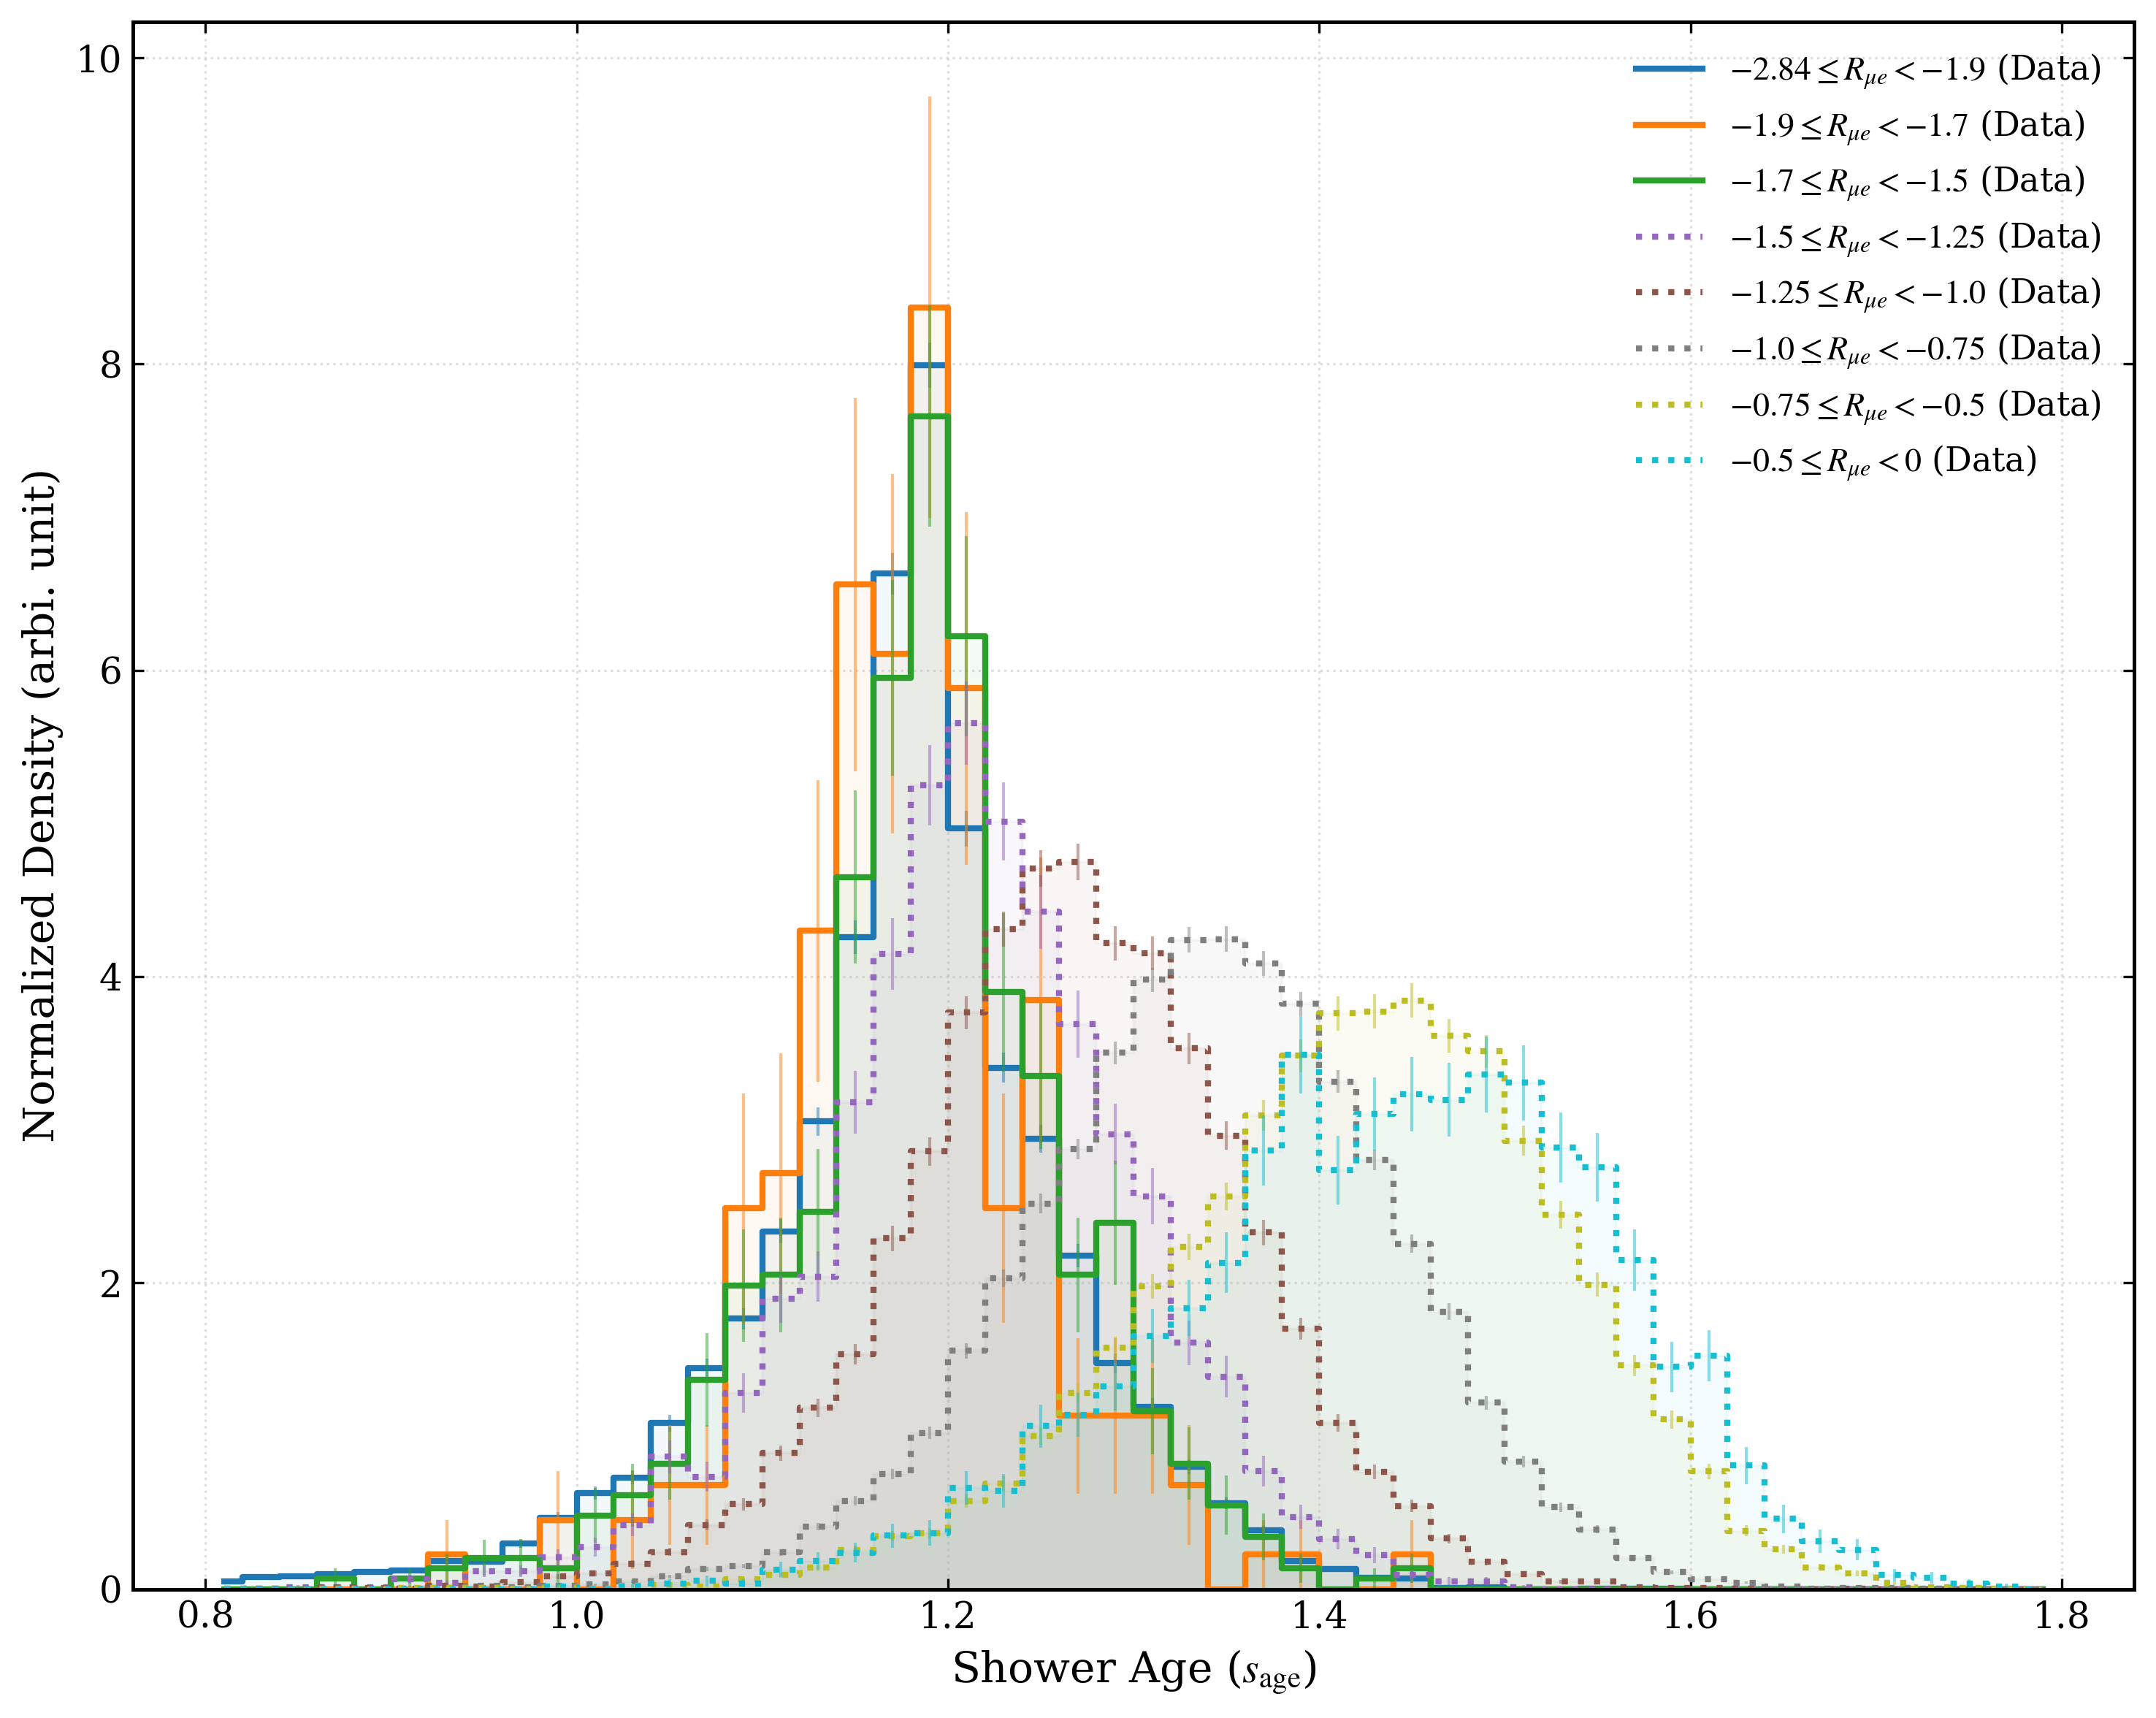

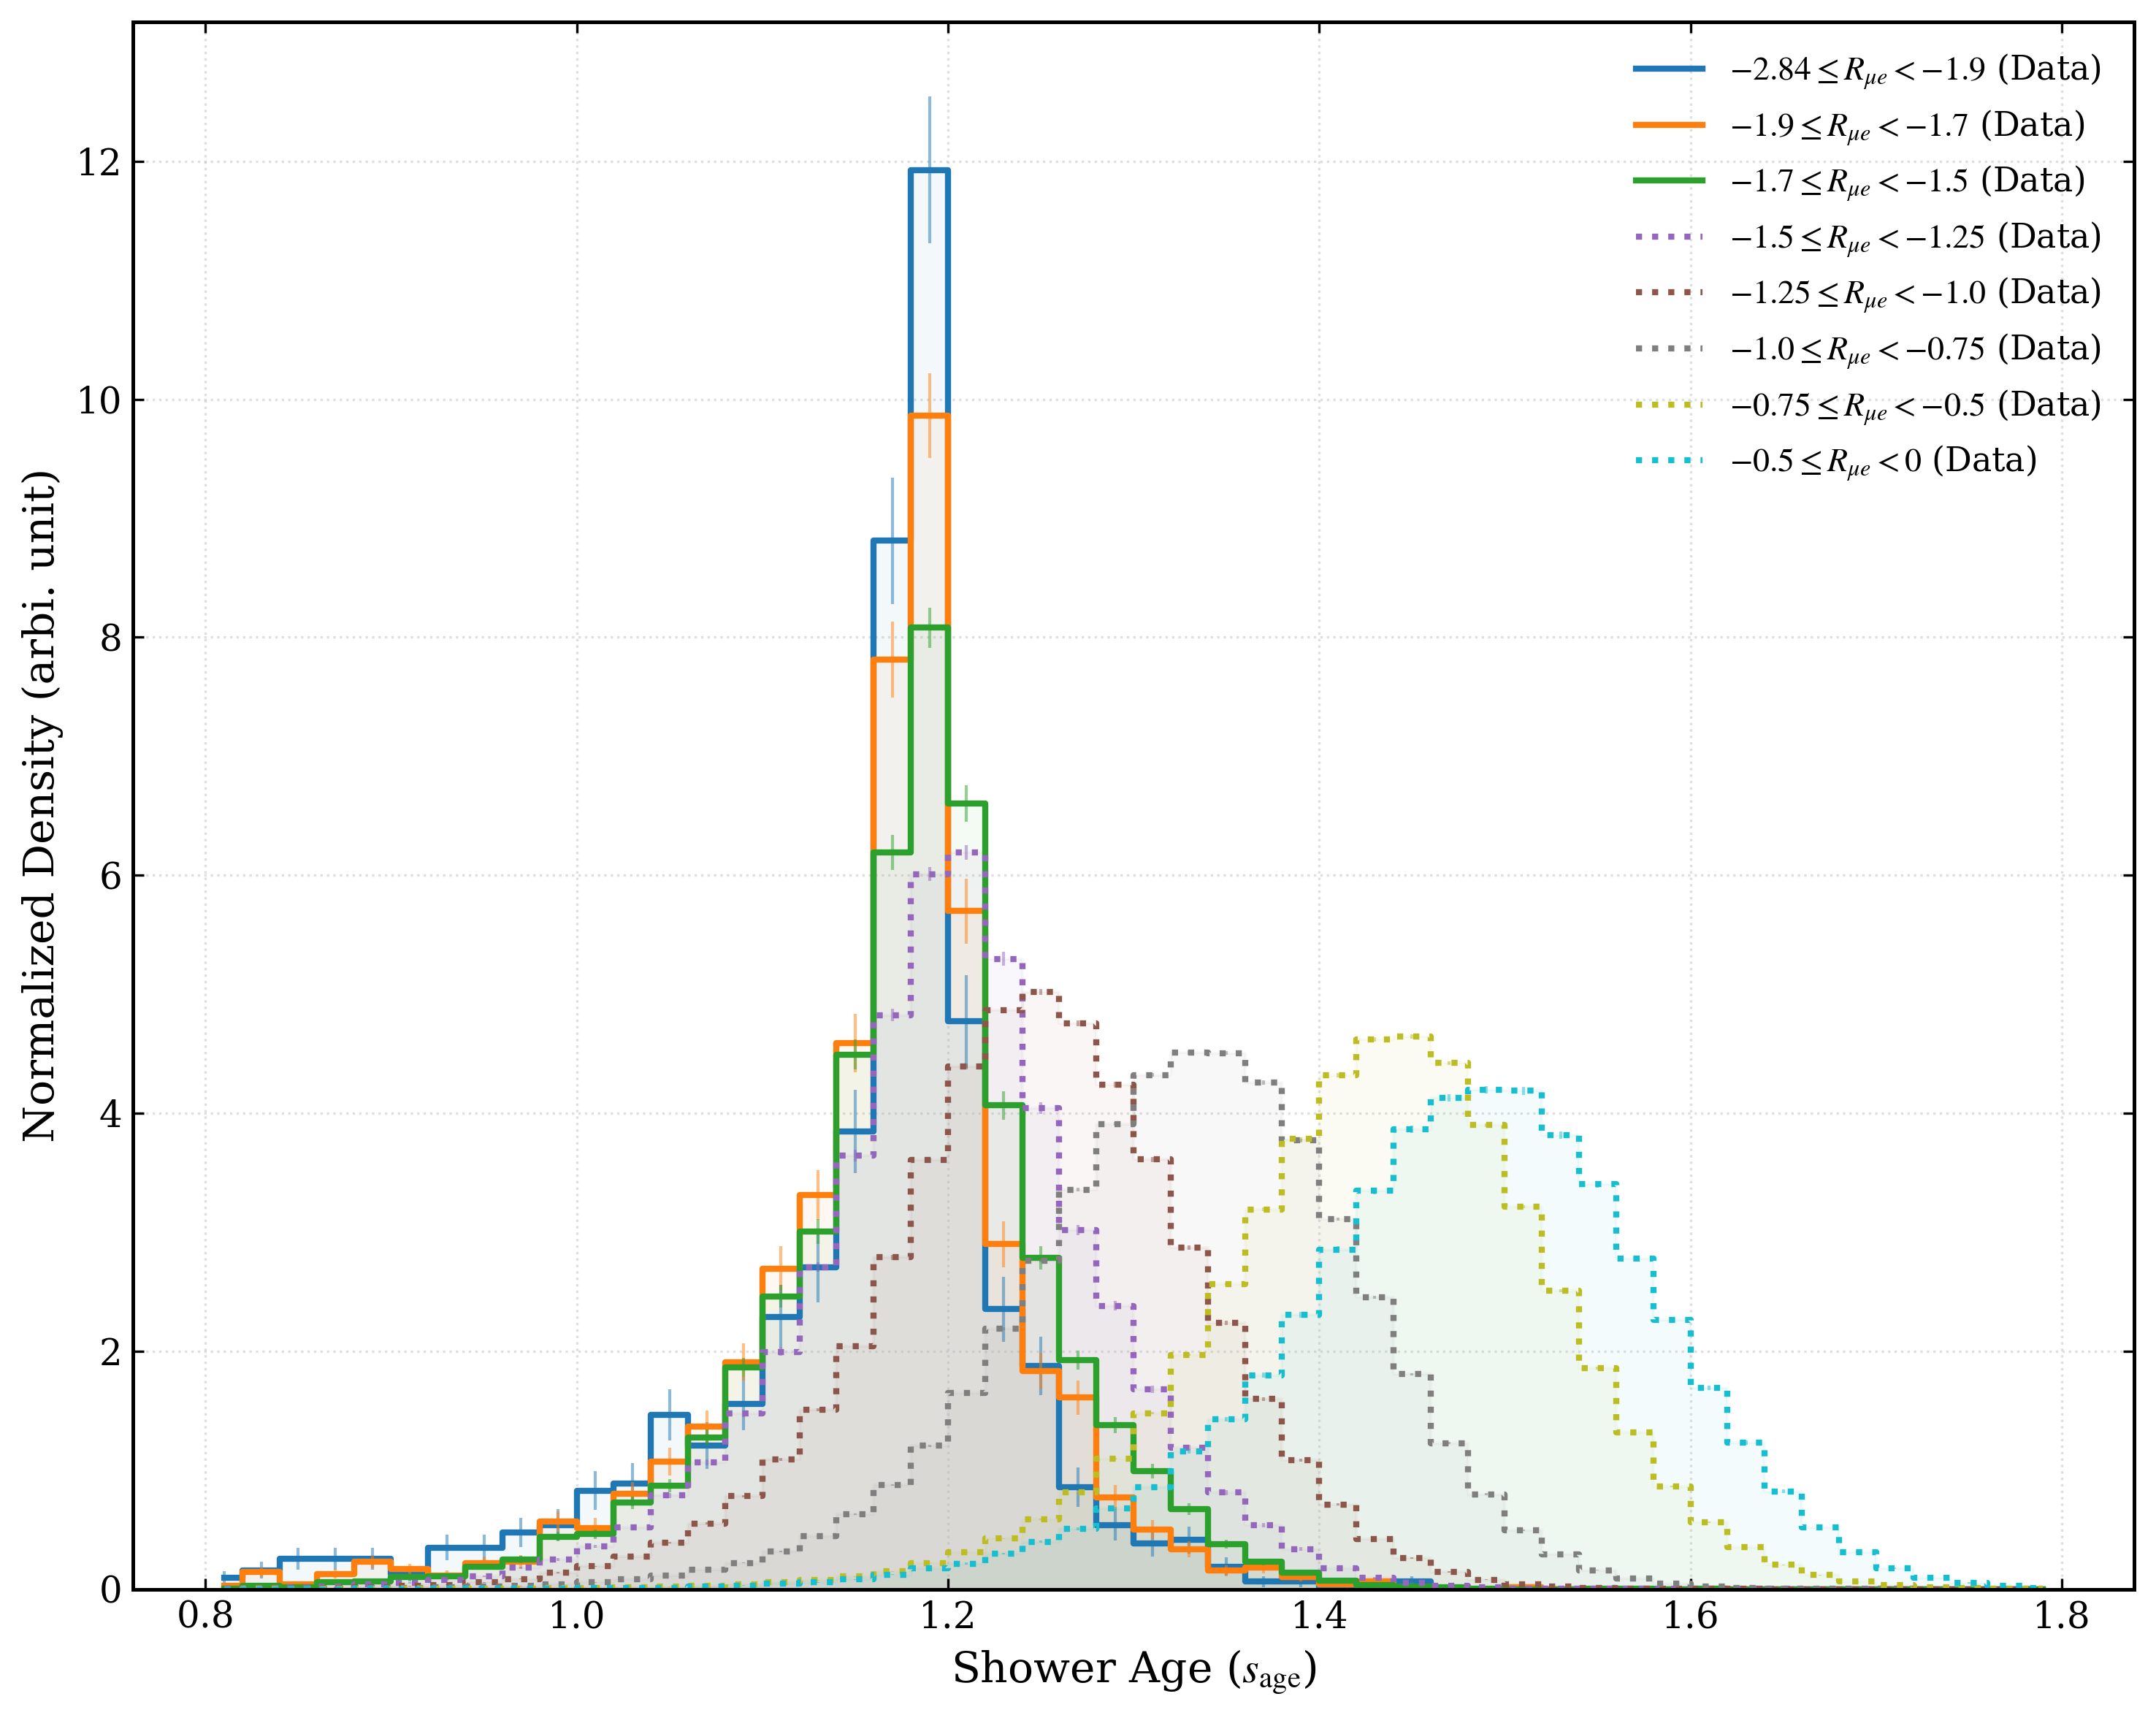

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_data_evolution_density(df_year, df_day, bins_config, var='Eage', figsize=(10, 8), filepath=None):
    # --- 1. 学术风格设置 (保持不变) ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.linewidth": 1.2,
        "xtick.top": True,
        "ytick.right": True
    })

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    # colors = plt.cm.magma(np.linspace(0, 0.9, len(bins_config)))
    colors = plt.cm.tab10(np.linspace(0, 1, len(bins_config)))
    # r'$\rho_{40}$ [m$^{-2}$]'
    var_info = {
        'Eage':  {'label': r'Shower Age ($s_{\mathrm{age}}$)', 'range': (0.8, 1.8), 'bins': 50},
        'pincness': {'label': 'Pincness', 'range': (0.5, 1), 'bins': 50},
        'rho40': {'label': r'$\rho_{40}$ [m$^{-2}$]', 'range': (0, 150), 'bins': 50},
        'rec_theta': {'label': r'$\theta_{\mathrm{rec}}$ [rad]', 'range': np.deg2rad((10, 30)), 'bins': 50},
    }
    cfg = var_info.get(var, {'label': var, 'range': None, 'bins': 50})

    for i, (r_low, r_high) in enumerate(bins_config):
        # --- 数据源选择 ---
        if r_high <= -1.9:
            source_label, df_source, linestyle = "Data", df_year, '-'
        elif r_high > -1.9 and r_high <= -1.5:
            source_label, df_source, linestyle = "Data", df_day, '-'
        else:
            source_label, df_source, linestyle = "Data", df_day, ':'
            
        # --- 2. 关键修复：强制转换数据类型 ---
        mask = (df_source['R_ue'] >= r_low) & (df_source['R_ue'] < r_high)
        
        # 使用 pd.to_numeric 过滤掉潜在的非数字并强制转为 float64
        selected_series = pd.to_numeric(df_source.loc[mask, var], errors='coerce').dropna()
        slice_data = selected_series.values.astype(float)
        
     
        
        N_events = len(slice_data)
        if N_events == 0: continue

        # --- 3. 计算直方图 ---
        hist, bin_edges = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'], density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        
        # --- 4. 再次强制转换绘图数组类型 (防御性编程) ---
        hist = hist.astype(float)
        bin_centers = bin_centers.astype(float)

        raw_counts, _ = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'])
        valid_mask = raw_counts > 0
        yerr = np.zeros_like(hist)
        yerr[valid_mask] = hist[valid_mask] * (1.0 / np.sqrt(raw_counts[valid_mask]))

        # --- 5. 绘图 ---$N={N_events}$
        label_text = rf"${r_low} \leq R_{{\mu e}} < {r_high}$ ({source_label}) "
        
        ax.step(bin_centers, hist, where='mid', color=colors[i], linestyle=linestyle, linewidth=2, label=label_text)
        ax.errorbar(bin_centers[valid_mask], hist[valid_mask], yerr=yerr[valid_mask], 
                    fmt='none', ecolor=colors[i], elinewidth=1, capsize=0, alpha=0.5)
        
        # 这里之前报错，现在 hist 和 bin_centers 已经是纯粹的 float64 数组了
        ax.fill_between(bin_centers, hist, step='mid', color=colors[i], alpha=0.05)

    # --- 装饰 ---
    ax.set_xlabel(cfg['label'], fontsize=14)
    ax.set_ylabel("Normalized Density (arbi. unit)", fontsize=14)
    ax.legend(loc='best', frameon=False, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    if filepath is not None:
        print(f"Saving figure to {filepath} ...")
        plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
    plt.show()
print("Plotting Data Evolution...")
bins_to_compare = [
    (-2.84, -2.75),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    (-2.75, -2.5),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    (-2.5, -2.25),  # 过渡区/背景区, 使用 Day Data
    (-2.25, -1.9),  # 过渡区/背景区, 使用 Day Data
    (-1.9, -1.7), 
    (-1.7, -1.5), 
    (-1.5, -1.25),  # 如果需要，可以加更重的背景区
    (-1.25, -1.0),  # 如果需要，可以加更重的背景区
    (-1.0, -0.75),
    (-0.75, -0.5),
    (-0.5, -0),  # 如果需要，可以加更重的背景区
]

bins_to_compare = [
   
    (-2.84, -1.9),  # 过渡区/背景区, 使用 Day Data
    (-1.9, -1.7), 
    (-1.7, -1.5), 
    (-1.5, -1.25),  # 如果需要，可以加更重的背景区
    (-1.25, -1.0),  # 如果需要，可以加更重的背景区
    (-1.0, -0.75),
    (-0.75, -0.5),
    (-0.5, -0),  # 如果需要，可以加更重的背景区
]
plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='Eage', filepath="/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Data_age_stability_with_Rue.pdf")
plot_data_evolution_density(df_all_components, df_all_components, bins_to_compare, var='Eage',)

# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='pincness')
# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='rho40')
# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='rec_theta')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_data_evolution_density(df_year, df_day, bins_config, var='Eage', figsize=(10, 8), filepath=None):
    # --- 1. 学术风格设置 (保持不变) ---
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "axes.linewidth": 1.2,
        "xtick.top": True,
        "ytick.right": True
    })

    fig, ax = plt.subplots(figsize=figsize, dpi=300)
    # colors = plt.cm.magma(np.linspace(0, 0.9, len(bins_config)))
    colors = plt.cm.tab10(np.linspace(0, 1, len(bins_config)))
    # r'$\rho_{40}$ [m$^{-2}$]'
    var_info = {
        'Eage':  {'label': r'Shower Age ($s_{\mathrm{age}}$)', 'range': (0.8, 1.8), 'bins': 50},
        'pincness': {'label': 'Pincness', 'range': (0.5, 1), 'bins': 50},
        'rho40': {'label': r'$\rho_{40}$ [m$^{-2}$]', 'range': (0, 150), 'bins': 50},
        'rec_theta': {'label': r'$\theta_{\mathrm{rec}}$ [rad]', 'range': np.deg2rad((10, 30)), 'bins': 50},
    }
    cfg = var_info.get(var, {'label': var, 'range': None, 'bins': 50})

    for i, (r_low, r_high) in enumerate(bins_config):
        # --- 数据源选择 ---
        if r_high <= -1.9:
            source_label, df_source, linestyle = "Data", df_year, '-'
        elif r_high > -1.9 and r_high <= -1.5:
            source_label, df_source, linestyle = "Data", df_day, '-'
        else:
            source_label, df_source, linestyle = "Data", df_day, ':'
            
        # --- 2. 关键修复：强制转换数据类型 ---
        mask = (df_source['R_ue'] >= r_low) & (df_source['R_ue'] < r_high)
        
        # 使用 pd.to_numeric 过滤掉潜在的非数字并强制转为 float64
        selected_series = pd.to_numeric(df_source.loc[mask, var], errors='coerce').dropna()
        slice_data = selected_series.values.astype(float)
        
     
        
        N_events = len(slice_data)
        if N_events == 0: continue

        # --- 3. 计算直方图 ---
        hist, bin_edges = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'], density=True)
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        
        # --- 4. 再次强制转换绘图数组类型 (防御性编程) ---
        hist = hist.astype(float)
        bin_centers = bin_centers.astype(float)

        raw_counts, _ = np.histogram(slice_data, bins=cfg['bins'], range=cfg['range'])
        valid_mask = raw_counts > 0
        yerr = np.zeros_like(hist)
        yerr[valid_mask] = hist[valid_mask] * (1.0 / np.sqrt(raw_counts[valid_mask]))

        # --- 5. 绘图 ---$N={N_events}$
        label_text = rf"${r_low} \leq R_{{\mu e}} < {r_high}$ ({source_label}) "
        
        ax.step(bin_centers, hist, where='mid', color=colors[i], linestyle=linestyle, linewidth=2, label=label_text)
        ax.errorbar(bin_centers[valid_mask], hist[valid_mask], yerr=yerr[valid_mask], 
                    fmt='none', ecolor=colors[i], elinewidth=1, capsize=0, alpha=0.5)
        
        # 这里之前报错，现在 hist 和 bin_centers 已经是纯粹的 float64 数组了
        ax.fill_between(bin_centers, hist, step='mid', color=colors[i], alpha=0.05)

    # --- 装饰 ---
    ax.set_xlabel(cfg['label'], fontsize=14)
    ax.set_ylabel("Normalized Density (arbi. unit)", fontsize=14)
    ax.legend(loc='best', frameon=False, fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    if filepath is not None:
        print(f"Saving figure to {filepath} ...")
        plt.savefig(filepath, bbox_inches='tight', pad_inches=0.1)
    plt.show()
print("Plotting Data Evolution...")
bins_to_compare = [
    (-2.84, -2.75),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    (-2.75, -2.5),  # 极低 Muon 区 (Signal-like / Light), 使用 Year Data
    (-2.5, -2.25),  # 过渡区/背景区, 使用 Day Data
    (-2.25, -1.9),  # 过渡区/背景区, 使用 Day Data
    (-1.9, -1.7), 
    (-1.7, -1.5), 
    (-1.5, -1.25),  # 如果需要，可以加更重的背景区
    (-1.25, -1.0),  # 如果需要，可以加更重的背景区
    (-1.0, -0.75),
    (-0.75, -0.5),
    (-0.5, -0),  # 如果需要，可以加更重的背景区
]

bins_to_compare = [
   
    (-2.84, -1.9),  # 过渡区/背景区, 使用 Day Data
    (-1.9, -1.7), 
    (-1.7, -1.5), 
    (-1.5, -1.25),  # 如果需要，可以加更重的背景区
    (-1.25, -1.0),  # 如果需要，可以加更重的背景区
    (-1.0, -0.75),
    (-0.75, -0.5),
    (-0.5, -0),  # 如果需要，可以加更重的背景区
]
# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='Eage', filepath="/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Data_age_stability_with_Rue.pdf")
plot_data_evolution_density(df_all_components, df_all_components, bins_to_compare, var='Eage',)

# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='pincness')
# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='rho40')
# plot_data_evolution_density(exp_Rue_df, one_day_df, bins_to_compare, var='rec_theta')


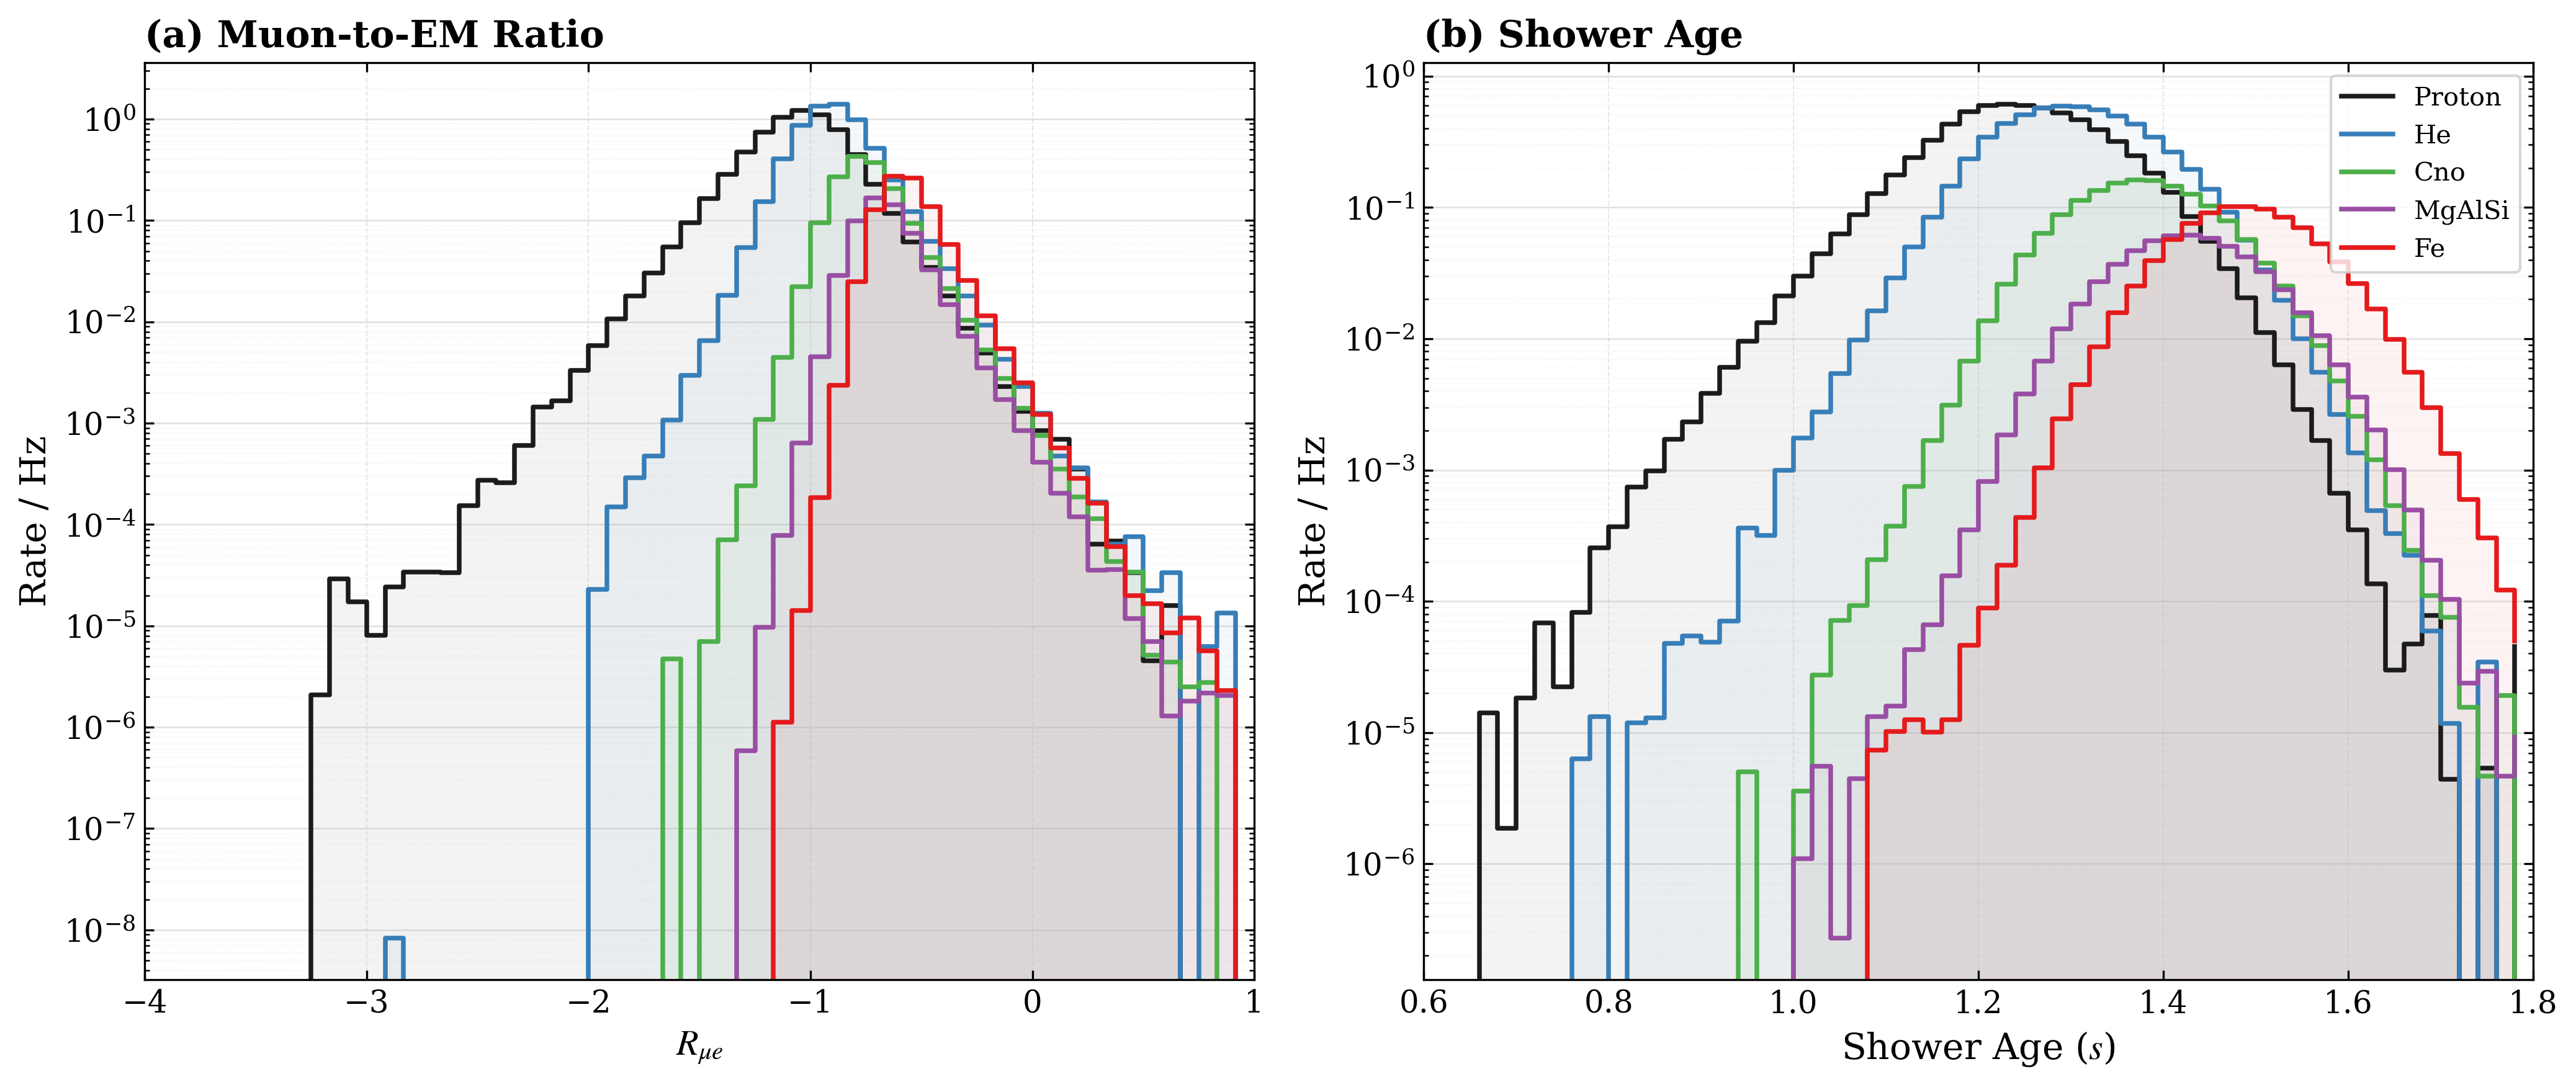

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import LogLocator, NullFormatter

def plot_composition_dual_panels(dfs, bins=60, figsize=(14, 6)):
    """
    绘制 R_ue 和 rec_Eage 的成分对比子图。
    要求：正式发表格式、加权统计、Y轴对数坐标及加密网格。
    """
    # 1. 学术风格与字体设置
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "serif"],
        "mathtext.fontset": "stix",
        "font.size": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.grid": True
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=300)

    # 成分颜色映射
    # 方案 A：经典学术对比色
    color_map = {
    "proton": "#1B1B1B", # 黑色 (作为基准成分)
    "he":     "#377eb8", # 蓝色
    "cno":    "#4daf4a", # 绿色
    "mgalsi": "#984ea3", # 紫色
    "fe":     "#e41a1c"  # 红色
    }
    species_order = ["proton", "he", "cno", "mgalsi", "fe"]

    # 参数配置：(变量名, x范围, x轴标签)
    configs = [
        ("R_ue", (-4, 1), r"$R_{\mu e}$", ax1),
        ("rec_Eage", (0.6, 1.8), r"Shower Age ($s$)", ax2)
    ]

    for p_name, x_range, x_label, ax in configs:
        for name in species_order:
            if name not in dfs or p_name not in dfs[name].columns:
                continue
            
            df = dfs[name]
            # 数据转换与权重提取
            vals = pd.to_numeric(df[p_name], errors='coerce').values
            weights = pd.to_numeric(df.get("weightGaisser", np.ones_like(vals)), errors='coerce').values
            
            # 过滤无效值
            mask = np.isfinite(vals) & np.isfinite(weights) & (vals >= x_range[0]) & (vals <= x_range[1])
            if not np.any(mask): continue

            # 计算加权直方图 (使用密度或计数，根据需求调整)
            counts, bin_edges = np.histogram(
                vals[mask], bins=bins, range=x_range, weights=weights[mask], 
            )
            bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
            # 绘图
            label_text = name.capitalize() if name != "mgalsi" else "MgAlSi"
            ax.step(bin_edges[:-1], counts, where='post', label=label_text, 
                    color=color_map[name], linewidth=1.8)
            ax.fill_between(bin_edges[:-1], counts, step='post', color=color_map[name], alpha=0.05)

        # 2. 坐标轴与密集网格美化
        ax.set_xlabel(x_label, fontsize=14)
        ax.set_ylabel("Rate / Hz", fontsize=14)
        ax.set_xlim(x_range)
        ax.set_yscale('log')
        # ax.set_ylim(1e-6, ) # 根据数据密度调整

        # 设置 Y 轴主次加密网格
        ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
        ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))
        ax.yaxis.set_minor_formatter(NullFormatter())

        # 线条样式：主网格实线，次网格极细点线
        ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.6, alpha=0.4)
        ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.4, alpha=0.2)
        ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.5, alpha=0.3)

    # 3. 标注与保存
    ax1.set_title(r"(a) Muon-to-EM Ratio", loc='left', fontweight='bold')
    ax2.set_title(r"(b) Shower Age", loc='left', fontweight='bold')
    ax2.legend(frameon=True, fontsize=10, loc='upper right', ncol=1,  shadow=False).get_frame().set_edgecolor('0.8')

    plt.tight_layout()
    plt.savefig("/data/home/zzh/Filt_Event/Note_Writing/figures/Composition_Rue_Age_Comparison.pdf", bbox_inches='tight')
    plt.show()

# 调用
plot_composition_dual_panels(dfs)


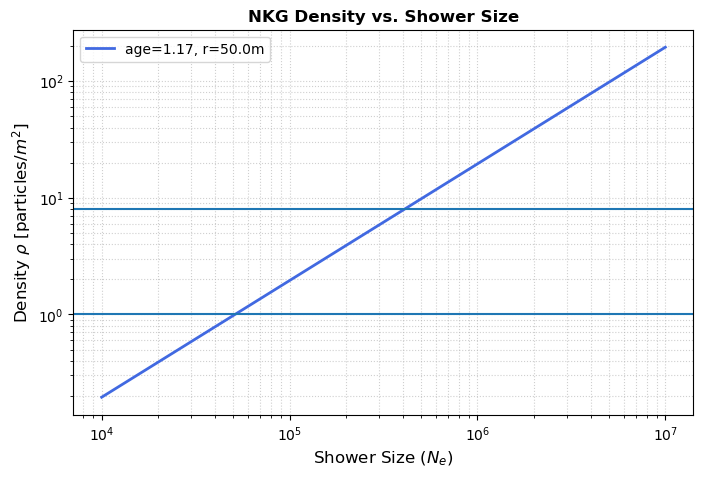

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma

def get_nkg_density(age, size, r):
    """
    NKG 密度分布函数
    :param age: 簇射年龄 (Shower age)
    :param size: 总粒子数 (Shower size / Ne)
    :param r: 到簇射核心的距离 [m]
    """
    if age < 0.6 or age > 2.4:
        return -10
    
    rm = 130.0  # Moliere radius
    
    # 计算归一化系数 Cs
    # C(s) = Γ(4.5-s) / [Γ(s) * Γ(4.5-2s)] 
    # 注意：C++ 代码里的 Gamma 参数逻辑需要精确对应
    term1 = gamma(4.5 - age)
    term2 = gamma(age)  # 对应 C++ 的 age - 2.5 + 2.0
    term3 = gamma(4.5 - 2.0 * age) # 对应 C++ 的 4.5 + 2.5 - 2.0 - 2.0*age
    
    cs = term1 / (term2 * term3)
    cs = cs / (2 * np.pi * rm**2)
    
    # 计算密度 rho
    rho = cs * size * (r/rm)**(age - 2) * (1 + r/rm)**(age - 4.5)
    return rho

# --- 设置参数 ---
age_val = 1.17
r_val = 50.0

# 设置 size 的变化范围 (通常 size 是以 10 的幂次变化的，例如 10^4 到 10^7)
sizes = np.logspace(4, 7, 100) 
densities = [get_nkg_density(age_val, s, r_val) for s in sizes]

# --- 绘图 ---
plt.figure(figsize=(8, 5))
plt.plot(sizes, densities, label=f'age={age_val}, r={r_val}m', linewidth=2, color='royalblue')
plt.axhline(1)
plt.axhline(8)
plt.xscale('log') # Size 通常用对数坐标显示
plt.yscale('log') # 密度也常呈现线性增长，对数坐标更清晰
plt.xlabel('Shower Size ($N_e$)', fontsize=12)
plt.ylabel('Density $\\rho$ [particles/$m^2$]', fontsize=12)
plt.title('NKG Density vs. Shower Size', fontweight='bold')
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()

plt.show()
